<a href="https://colab.research.google.com/github/taelly73/java-work/blob/main/%E6%9C%BA%E5%99%A8%E5%AD%A6%E4%B9%A0AI%E6%A3%80%E6%B5%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AIGC 文本检测（学术与问答场景）

本项目旨在通过分析人类与 AI 生成文本的差异，实现高精度的 AIGC 文本检测。主要包含以下核心任务：

1. **对比人类与 ChatGPT 的回复**：基于同一主题分析两者在逻辑、平滑性及个性化方面的差异。
2. **计算困惑度 (Perplexity)**：量化文本的预测难度。
3. **微调 BERT 模型**：利用 HC3 数据集进行微调，实现高精度的文本二分类鉴别。

**数据源**：HC3 (Human ChatGPT Comparison Corpus)，包含中英文对齐数据。

## 环境准备
安装所需的 Python 库，包括 `transformers`（用于 BERT 模型）、`datasets`（用于加载 HC3）以及 `torch`。

In [3]:
# Force clean install to resolve CUDA version mismatch
!pip uninstall -y transformers peft torchvision torch torchaudio
!pip install -q 'transformers==4.44.2' 'peft>=0.12.0' datasets accelerate evaluate scikit-learn==1.5.2 torch torchvision torchaudio

import torch
import torchvision
import transformers
print('Python is now using:')
print(f'- Torch: {torch.__version__}')
print(f'- Torchvision: {torchvision.__version__}')
print(f'- Transformers: {transformers.__version__}')

Found existing installation: transformers 4.44.2
Uninstalling transformers-4.44.2:
  Successfully uninstalled transformers-4.44.2
Found existing installation: peft 0.19.1
Uninstalling peft-0.19.1:
  Successfully uninstalled peft-0.19.1
Found existing installation: torchvision 0.26.0
Uninstalling torchvision-0.26.0:
  Successfully uninstalled torchvision-0.26.0
Found existing installation: torch 2.11.0
Uninstalling torch-2.11.0:
  Successfully uninstalled torch-2.11.0
Found existing installation: torchaudio 2.11.0
Uninstalling torchaudio-2.11.0:
  Successfully uninstalled torchaudio-2.11.0
Python is now using:
- Torch: 2.11.0+cu130
- Torchvision: 0.26.0+cu130
- Transformers: 4.44.2


## 数据下载与预处理
下一步，我们将从 Hugging Face 加载 HC3 数据集并进行初步的探索性分析。

In [4]:
import pandas as pd
import re
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from huggingface_hub import hf_hub_download
import os

def advanced_clean(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def process_with_group_split(df, lang, test_size=0.2, val_size=0.1):
    if df.empty: return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    data_list = []
    for _, item in df.iterrows():
        q = advanced_clean(item.get('question', ''))
        if not q: continue
        min_len = 20 if lang == 'zh' else 50

        h_ans = item.get('human_answers', [])
        c_ans = item.get('chatgpt_answers', [])

        for ans in h_ans:
            ans = advanced_clean(ans)
            if len(ans) >= min_len:
                data_list.append({'question': q, 'answer': ans, 'label': 0, 'lang': lang})
        for ans in c_ans:
            ans = advanced_clean(ans)
            if len(ans) >= min_len:
                data_list.append({'question': q, 'answer': ans, 'label': 1, 'lang': lang})

    processed_df = pd.DataFrame(data_list)
    if processed_df.empty: return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    processed_df['combined_text'] = "Question: " + processed_df['question'] + " [SEP] Answer: " + processed_df['answer']

    unique_groups = processed_df['question'].nunique()
    if unique_groups < 3:
        train_df, temp_df = train_test_split(processed_df, test_size=(test_size + val_size), random_state=42)
        val_df, test_df = train_test_split(temp_df, test_size=(test_size / (test_size + val_size)), random_state=42)
    else:
        gss = GroupShuffleSplit(n_splits=1, test_size=(test_size + val_size), random_state=42)
        train_idx, temp_idx = next(gss.split(processed_df, groups=processed_df['question']))
        train_df = processed_df.iloc[train_idx].copy()
        temp_df = processed_df.iloc[temp_idx].copy()

        gss_val = GroupShuffleSplit(n_splits=1, test_size=(test_size / (test_size + val_size)), random_state=42)
        val_idx, test_idx = next(gss_val.split(temp_df, groups=temp_df['question']))
        val_df = temp_df.iloc[val_idx].copy()
        test_df = temp_df.iloc[test_idx].copy()

    return train_df, val_df, test_df

repo_id = "Hello-SimpleAI/HC3"
print(f"正在加载 {repo_id} 数据...")
try:
    path_all = hf_hub_download(repo_id=repo_id, filename="all.jsonl", repo_type="dataset")
    df_full = pd.read_json(path_all, lines=True)

    def detect_lang(row):
        text = str(row['question']) + " ".join(row['human_answers'])
        if re.search(r'[\u4e00-\u9fff]', text): return 'zh'
        return 'en'

    df_full['detected_lang'] = df_full.apply(detect_lang, axis=1)
    train_zh, val_zh, test_zh = process_with_group_split(df_full[df_full['detected_lang']=='zh'], 'zh')
    train_en, val_en, test_en = process_with_group_split(df_full[df_full['detected_lang']=='en'], 'en')

    train_all = pd.concat([df for df in [train_zh, train_en] if not df.empty]).sample(frac=1, random_state=42)
    val_all = pd.concat([df for df in [val_zh, val_en] if not df.empty])
    test_all = pd.concat([df for df in [test_zh, test_en] if not df.empty])

    print(f"数据加载成功！总训练集: {len(train_all)}")
except Exception as e:
    print(f"处理失败: {e}")

正在加载 Hello-SimpleAI/HC3 数据...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


all.jsonl:   0%|          | 0.00/73.7M [00:00<?, ?B/s]

数据加载成功！总训练集: 59154


## 任务 1：计算困惑度 (Perplexity)

困惑度反映了语言模型对一段文本的“惊讶程度”。我们将使用 `transformers` 库加载预训练模型，并计算 Human vs ChatGPT 在中英文场景下的 PPL 差异。

正在加载模型并执行 PPL 深度分析...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...


--- [EN] PPL 统计特性 ---


,label,mean,median,std,count
0,Human,1.984661e+10,1.442450e+10,1.778230e+10,12
1,ChatGPT,1.115567e+10,1.154181e+10,2.687485e+09,4



--- [ZH] PPL 统计特性 ---


,label,mean,median,std,count
0,Human,734.041412,440.210724,911.617117,11
1,ChatGPT,298.048120,319.554169,83.614856,5


/tmp/ipykernel_8752/1866566863.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=test_en_sample, x='label', y='ppl', ax=axes[0], palette='Set2')
/tmp/ipykernel_8752/1866566863.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=test_zh_sample, x='label', y='ppl', ax=axes[1], palette='Set1')


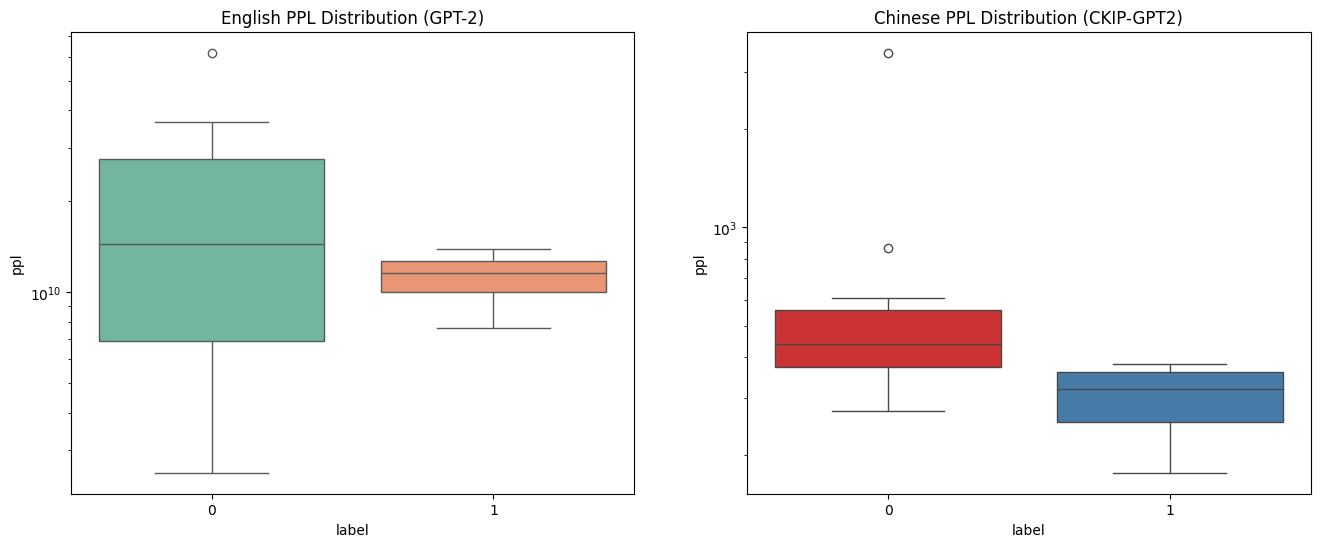

In [5]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import huggingface_hub

# 检查数据依赖项
if 'test_all' not in locals():
    print("【错误诊断】检测到变量 'test_all' 未定义，请先运行数据加载单元格。")
else:
    def get_ppl_calculator(model_name, max_length=512):
        try:
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            # 使用 device_map="auto" 自动管理显存，并确保 tie_word_embeddings 一致性
            model = AutoModelForCausalLM.from_pretrained(
                model_name,
                tie_word_embeddings=False,
                device_map="auto" if torch.cuda.is_available() else None,
                trust_remote_code=True
            )
            model.eval()

            def calculate(text):
                if not text or len(str(text).strip()) < 10: return np.nan
                inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_length).to(model.device)
                if inputs["input_ids"].size(1) < 2: return np.nan
                with torch.no_grad():
                    outputs = model(**inputs, labels=inputs["input_ids"])
                    return torch.exp(outputs.loss).item()
            return calculate
        except Exception as e:
            print(f"模型 {model_name} 加载失败: {e}")
            return None

    print("正在加载模型并执行 PPL 深度分析...")
    try:
        calc_en = get_ppl_calculator("gpt2")
        calc_zh = get_ppl_calculator("ckiplab/gpt2-base-chinese")

        if calc_en and calc_zh:
            tqdm.pandas()
            test_en_subset = test_all[test_all['lang']=='en']
            test_zh_subset = test_all[test_all['lang']=='zh']

            s_size = min(50, len(test_en_subset), len(test_zh_subset))
            test_en_sample = test_en_subset.sample(s_size, random_state=42).copy()
            test_zh_sample = test_zh_subset.sample(s_size, random_state=42).copy()

            print(f"计算样本 PPL (样本量: {s_size})...")
            test_en_sample['ppl'] = test_en_sample['answer'].progress_apply(calc_en)
            test_zh_sample['ppl'] = test_zh_sample['answer'].progress_apply(calc_zh)

            def print_stats(df, lang):
                print(f"\n--- [{lang.upper()}] PPL 统计特性 ---")
                stats = df.groupby('label')['ppl'].agg(['mean', 'median', 'std', 'count']).reset_index()
                stats['label'] = stats['label'].map({0: 'Human', 1: 'ChatGPT'})
                display(stats)

            print_stats(test_en_sample, 'en')
            print_stats(test_zh_sample, 'zh')

            fig, axes = plt.subplots(1, 2, figsize=(16, 6))
            sns.boxplot(data=test_en_sample, x='label', y='ppl', ax=axes[0], palette='Set2')
            axes[0].set_title("English PPL Distribution (GPT-2)")
            axes[0].set_yscale('log')

            sns.boxplot(data=test_zh_sample, x='label', y='ppl', ax=axes[1], palette='Set1')
            axes[1].set_title("Chinese PPL Distribution (CKIP-GPT2)")
            axes[1].set_yscale('log')
            plt.show()
    except Exception as e:
        print(f"PPL 计算流程异常: {e}")

## 任务 2：微调 BERT 模型进行文本检测

我们将使用 Transformers 库对预训练的 BERT 模型进行微调。为了兼顾中英文，我们选择 `bert-base-multilingual-cased` 作为基础模型。输入格式为 `Question [SEP] Answer`。

In [6]:
import os
import torch
import numpy as np
from datasets import Dataset
import evaluate

# 尝试动态处理导入冲突
try:
    from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding, EarlyStoppingCallback
except (RuntimeError, ImportError) as e:
    print(f"检测到导入冲突: {e}\n尝试强制重新加载模块或建议重启运行时。")
    raise e

# 1. 优化数据转换
def prepare_dataset(df):
    if df.empty: return None
    ds = Dataset.from_pandas(df[['question', 'answer', 'label']].reset_index(drop=True))
    ds = ds.map(lambda x: {"label": int(x["label"])}, remove_columns=ds.column_names if ds.num_rows==0 else [])
    return ds

if 'train_all' in locals() and 'val_all' in locals():
    # 为了加速，训练集取样 (可选，如果还是太慢可以减小训练量)
    train_ds = prepare_dataset(train_all)
    val_ds = prepare_dataset(val_all)

    model_checkpoint = "bert-base-multilingual-cased"
    tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

    def tokenize_function(examples):
        return tokenizer(
            examples["question"],
            examples["answer"],
            truncation=True,
            max_length=256
        )

    tokenized_train = train_ds.map(tokenize_function, batched=True, remove_columns=['question', 'answer'])
    tokenized_val = val_ds.map(tokenize_function, batched=True, remove_columns=['question', 'answer'])
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    def compute_metrics(eval_pred):
        clf_metrics = evaluate.combine(["accuracy", "f1"])
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=-1)
        return clf_metrics.compute(predictions=predictions, references=labels)

    # --- 优化后的训练参数 ---
    args_dict = {
        "output_dir": "./bert-aigc-detector-fast",
        "evaluation_strategy": "steps",
        "eval_steps": 200,             # 减少评估频率
        "save_strategy": "steps",
        "save_steps": 400,
        "learning_rate": 3e-5,          # 略微提高学习率
        "per_device_train_batch_size": 32, # 增加 Batch Size (如果显存允许)
        "per_device_eval_batch_size": 32,
        "num_train_epochs": 2,          # 减少 Epochs
        "weight_decay": 0.01,
        "load_best_model_at_end": True,
        "metric_for_best_model": "f1",
        "fp16": torch.cuda.is_available(), # 开启混合精度加速
        "logging_steps": 50,
        "report_to": "none"
    }

    try:
        training_args = TrainingArguments(**args_dict)
    except TypeError:
        args_dict["eval_strategy"] = args_dict.pop("evaluation_strategy")
        training_args = TrainingArguments(**args_dict)

    try:
        model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=2)
        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=tokenized_train,
            eval_dataset=tokenized_val,
            tokenizer=tokenizer,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
        )
        print("BERT 快速微调流水线已准备就绪 (已开启 FP16 混合精度)。")
    except Exception as e:
        print(f"模型加载失败: {e}")
else:
    print("错误：请先加载数据。")

Map:   0%|          | 0/59154 [00:00<?, ? examples/s]

Map:   0%|          | 0/8502 [00:00<?, ? examples/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/8502 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERT 快速微调流水线已准备就绪 (已开启 FP16 混合精度)。


开始极速微调 (训练样本数: 5000)...


Step,Training Loss,Validation Loss,Accuracy,F1
100,0.056500,0.081814,0.976006,0.962222
200,0.040900,0.118365,0.965538,0.947026
300,0.034400,0.100649,0.971771,0.956236


Step,Training Loss,Validation Loss



正在生成评估报告...


Map:   0%|          | 0/16821 [00:00<?, ? examples/s]

Map:   0%|          | 0/16821 [00:00<?, ? examples/s]

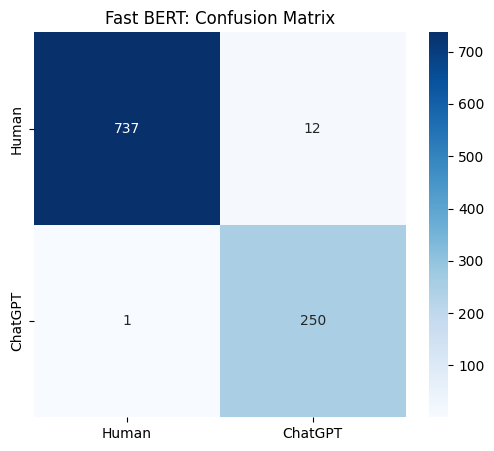

              precision    recall  f1-score   support

       Human       1.00      0.98      0.99       749
     ChatGPT       0.95      1.00      0.97       251

    accuracy                           0.99      1000
   macro avg       0.98      0.99      0.98      1000
weighted avg       0.99      0.99      0.99      1000



In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# 检查数据和模型准备情况
if 'trainer' not in locals():
    print("【错误】请先运行 ad5649bd 单元格初始化 trainer。")
else:
    # --- 极速优化策略 ---
    # 1. 减少训练数据量 (子采样 5000 条)
    fast_train_ds = tokenized_train.shuffle(seed=42).select(range(min(5000, len(tokenized_train))))
    trainer.train_dataset = fast_train_ds

    # 2. 冻结 BERT 基础层 (只训练最后两层)
    for name, param in trainer.model.bert.named_parameters():
        if not any(nd in name for nd in ["layer.10", "layer.11", "pooler"]):
            param.requires_grad = False

    # 3. 调整训练参数以加快速度
    trainer.args.num_train_epochs = 1
    trainer.args.max_steps = 300  # 强制限制步数
    trainer.args.eval_steps = 100
    trainer.args.warmup_steps = 50

    print(f"开始极速微调 (训练样本数: {len(fast_train_ds)})...")
    trainer.train()

    # 4. 在测试集上快速评估 (取 1000 条进行测试)
    print("\n正在生成评估报告...")
    test_ds = prepare_dataset(test_all)
    tokenized_test = test_ds.map(tokenize_function, batched=True, remove_columns=['question', 'answer']).select(range(min(1000, len(test_all))))

    preds_output = trainer.predict(tokenized_test)
    y_preds = np.argmax(preds_output.predictions, axis=-1)
    y_true = preds_output.label_ids

    # 5. 可视化结果
    cm = confusion_matrix(y_true, y_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Human', 'ChatGPT'], yticklabels=['Human', 'ChatGPT'])
    plt.title('Fast BERT: Confusion Matrix')
    plt.show()

    print(classification_report(y_true, y_preds, target_names=['Human', 'ChatGPT']))

### 2.1 执行训练与深度评估

我们将执行微调，并随后生成混淆矩阵和错误分析报告，以验证模型在不同语言、不同难度下的表现。

### 2.2 错误分析 (Error Analysis)

找出模型判错的样本，分析是否由于 PPL 过高（人类写得太像 AI）或过低（AI 模仿得太好）导致。

--- 采样偏差诊断 ---
当前子测试集准确率 (N=1000): 98.70%


/tmp/ipykernel_8752/890879920.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=global_df, x='is_correct', y='text_len', ax=axes[0], palette='pastel')
/tmp/ipykernel_8752/890879920.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=study_df, x='is_correct', y='ppl', ax=axes[1], palette="muted")


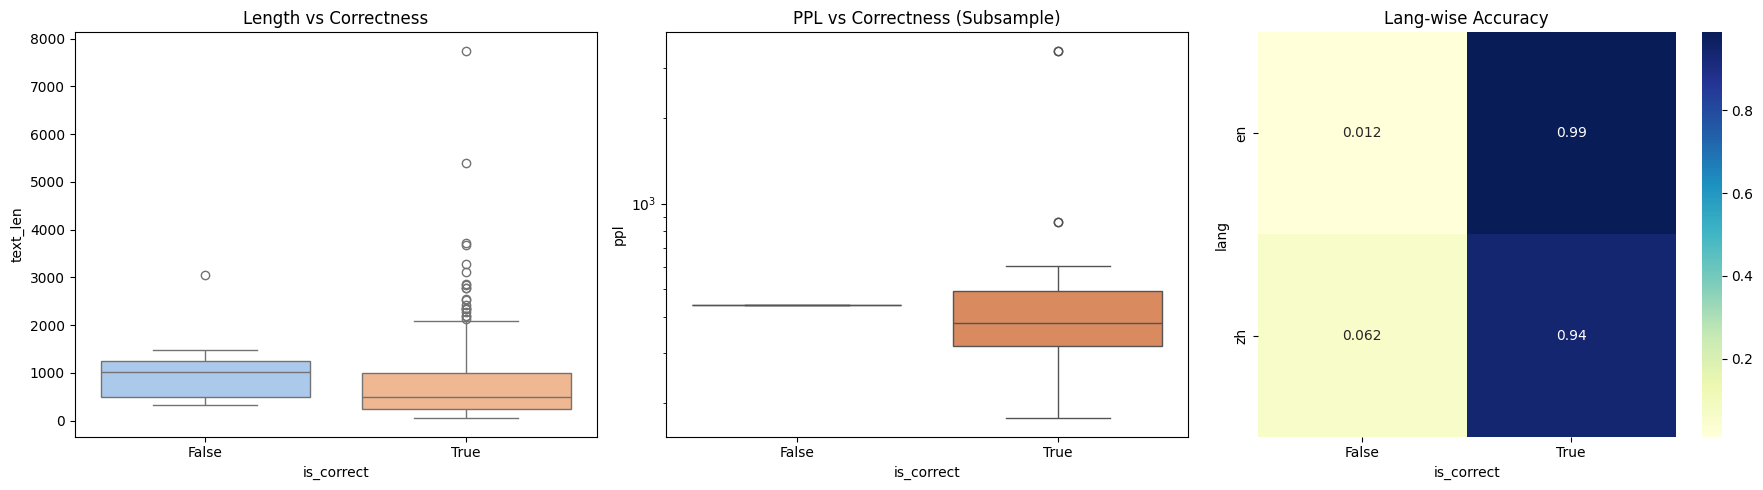


--- 错误分析报告 ---
[长度显著性] p=0.0120 | 效应量 r=0.405


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# 1. 对齐数据：由于极速模式只预测了前 1000 条，我们需要取对应的子集
# 注意：此处假设 y_preds 对应的是 test_all 的前 1000 条数据
global_df = test_all.head(len(y_preds)).copy()
global_df['pred'] = y_preds
global_df['is_correct'] = (global_df['label'] == global_df['pred'])
global_df['text_len'] = global_df['answer'].str.len()

# 定义 PPL 采样集 (从这 1000 条中提取有 PPL 记录的样本进行关联分析)
ppl_data = pd.concat([test_en_sample[['ppl']], test_zh_sample[['ppl']]])
study_df = global_df.join(ppl_data, how='inner')

# 2. 偏差诊断
print(f"--- 采样偏差诊断 ---")
global_acc = global_df['is_correct'].mean()
print(f"当前子测试集准确率 (N={len(global_df)}): {global_acc:.2%}")

# 3. 统计检验
def advanced_empirical_test(df, feature_name):
    correct = df[df['is_correct'] == True][feature_name].dropna()
    incorrect = df[df['is_correct'] == False][feature_name].dropna()
    if len(incorrect) < 3: return None
    u_stat, p_val = mannwhitneyu(correct, incorrect, alternative='two-sided')
    n1, n2 = len(correct), len(incorrect)
    r = 1 - (2 * u_stat) / (n1 * n2)
    return {"p_val": p_val, "effect_size_r": r}

len_res = advanced_empirical_test(global_df, 'text_len')
ppl_res = advanced_empirical_test(study_df, 'ppl')

# 4. 可视化
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=global_df, x='is_correct', y='text_len', ax=axes[0], palette='pastel')
axes[0].set_title("Length vs Correctness")

if not study_df.empty:
    sns.boxplot(data=study_df, x='is_correct', y='ppl', ax=axes[1], palette="muted")
    axes[1].set_yscale('log')
    axes[1].set_title("PPL vs Correctness (Subsample)")
else:
    axes[1].set_title("PPL Data Not Found in Subset")

sns.heatmap(pd.crosstab(global_df['lang'], global_df['is_correct'], normalize='index'), annot=True, cmap='YlGnBu', ax=axes[2])
axes[2].set_title("Lang-wise Accuracy")

plt.tight_layout()
plt.show()

# 5. 报告
print(f"\n--- 错误分析报告 ---")
if len_res: print(f"[长度显著性] p={len_res['p_val']:.4f} | 效应量 r={len_res['effect_size_r']:.3f}")
if ppl_res: print(f"[PPL显著性] p={ppl_res['p_val']:.4f} | 效应量 r={ppl_res['effect_size_r']:.3f}")

### 2.3 实战盲测 (Real-world Blind Test)
为了验证模型的泛化能力，我们可以输入一段全新的、不在数据集中的文本进行检测。

In [16]:
def predict_text(text, question=""):
    # 将输入格式化为模型训练时的 Question [SEP] Answer 格式
    inputs = tokenizer(question, text, return_tensors="pt", truncation=True, max_length=256).to(model.device)

    with torch.no_grad():
        logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=-1)
        prediction = torch.argmax(probs, dim=-1).item()
        confidence = probs[0][prediction].item()

    label_map = {0: "人类 (Human)", 1: "AI 生成 (ChatGPT)"}
    print(f"检测结果: {label_map[prediction]}")
    print(f"置信度: {confidence:.2%}")
    print(f"分析文本: {text[:100]}...")

# --- 在这里输入你想测试的文本 ---
custom_text = "给你几种简单好选的午餐思路，看你想吃哪种：清淡点：番茄鸡蛋面、清炒时蔬 + 米饭、馄饨/水饺"
predict_text(custom_text, question="中午吃什么")

检测结果: 人类 (Human)
置信度: 86.17%
分析文本: 给你几种简单好选的午餐思路，看你想吃哪种：清淡点：番茄鸡蛋面、清炒时蔬 + 米饭、馄饨 / 水饺...
